In [1]:
import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import numpy.random as nr
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy
import pickle

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))


from src.safe_routing import*
from src.preprocess import preprocess_df
from src.network_connectivity import ConnectivityUnit

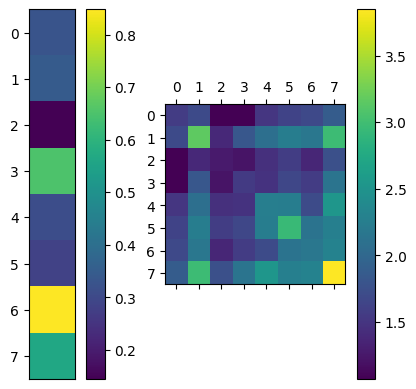

In [2]:
seed = 232# 232
np.random.seed(seed)

n_max = 8
mu_all = nr.rand(n_max)#np.zeros(n_max)  # nr.rand(n_max)
A_all = nr.rand(n_max, n_max)
cov_all = np.dot(A_all, A_all.T)

ax1 = plt.subplot(121)
mat1 = ax1.matshow(mu_all.reshape((-1, 1)))
plt.colorbar(mat1)
ax1.set_xticks([], [])
ax2 = plt.subplot(122)
mat2 = ax2.matshow(cov_all)
plt.colorbar(mat2)


In [4]:
res_df = pd.DataFrame()
all_true_mean = []
n_dims = list(np.arange(3, n_max, 1))
for n_dim in n_dims:
    print(n_dim)
    mu = mu_all[:n_dim]
    cov = cov_all[:n_dim, :n_dim]
    #temp_df = naive_mc_max(mu, cov, 10000, 10)
    temp_df['n_dim'] = n_dim
    res_df = pd.concat((res_df, temp_df))
    all_true_mean.append(calc_mean_max(cov, mu))


3
4
5
6
7


In [15]:
import time

n_max = 8
mu_all = nr.rand(n_max)#np.zeros(n_max)  # nr.rand(n_max)
A_all = nr.rand(n_max, n_max)
cov_all = np.dot(A_all, A_all.T)
n_dim = 8

mu = mu_all[:n_dim]
cov = cov_all[:n_dim, :n_dim]

start = time.time()
calc_mean_max(cov, mu)
#temp_df = naive_mc_max(mu, cov, 10000, 10)
end = time.time()
print(end - start)


73.90212535858154


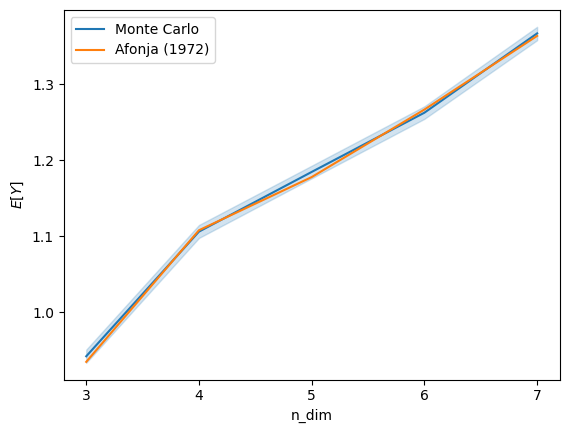

In [6]:
sns.lineplot(data=res_df, x='n_dim', y='max', label='Monte Carlo')
plt.plot(n_dims, all_true_mean, label='Afonja (1972)')
plt.ylabel(r'$E[Y]$')
plt.xticks([i for i in n_dims], [i for i in n_dims])
plt.legend()

In [19]:
all_true_mean

[0.9342835750223697,
 1.1077661470152813,
 1.1778591546398856,
 1.2668770677049193,
 1.3640323919068835]

# Simple Safe Routing on CIC-IDS-2017

In [2]:
import importlib, src

importlib.reload(src.safe_routing)
from src.safe_routing import*

In [3]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df = preprocess_df(df_cic, date_col=' Timestamp')



In [4]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [7]:
with open(r'saves\monday_freq_1000.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [14]:
with open(r'saves\monday_759.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [7]:
with open(r'saves\partitioned_nodes_141.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [5]:
len(entity_names)

13

In [6]:
g = communication_graph_from_df(df, entity_names, keep_outsiders=False)
entity_names = list(g.nodes)
len(g), len(entity_names)

(13, 13)

In [7]:
len(entity_names), len(g)

(13, 13)

In [8]:
pos = nx.spring_layout(g)
nx.draw(g, pos=pos_f, with_labels=False)

NameError: name 'pos_f' is not defined

In [10]:
import importlib, src, src.analyze_cic_ids

importlib.reload(src.analyze_cic_ids)
from src.analyze_cic_ids import*

In [3]:
import importlib, src, src.kalman_network_tools

importlib.reload(src.kalman_network_tools)
from src.kalman_network_tools import*

In [9]:
from src.analyze_cic_ids import get_risk_mat_from_df

risk_mat, labels, labels_count, _, _, all_cov = get_risk_mat_from_df(df, entity_names=entity_names, t_graph=90, sync_window_size=1.2,
                                                                    return_cov=True)
risk_mean, risk_cov = risk_mat[-1,:], all_cov[-1]

with open(r'saves\risks_13.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump((risk_mean, risk_cov), handle, protocol=pickle.HIGHEST_PROTOCOL)


1
Current time and samples shape:  2017-04-07 01:02:00 (75, 13)
2
Current time and samples shape:  2017-04-07 01:04:00 (75, 13)
3
Current time and samples shape:  2017-04-07 01:06:00 (75, 13)
4
Current time and samples shape:  2017-04-07 01:08:00 (75, 13)
5
Current time and samples shape:  2017-04-07 01:10:00 (75, 13)
6
Current time and samples shape:  2017-04-07 01:12:00 (75, 13)
7
Current time and samples shape:  2017-04-07 01:14:00 (75, 13)
8
Current time and samples shape:  2017-04-07 01:16:00 (75, 13)
9
Current time and samples shape:  2017-04-07 01:18:00 (75, 13)
10
Current time and samples shape:  2017-04-07 01:20:00 (75, 13)
11
Current time and samples shape:  2017-04-07 01:22:00 (75, 13)
12
Current time and samples shape:  2017-04-07 01:24:00 (75, 13)
13
Current time and samples shape:  2017-04-07 01:26:00 (75, 13)
14
Current time and samples shape:  2017-04-07 01:28:00 (75, 13)
15
Current time and samples shape:  2017-04-07 01:30:00 (75, 13)
16
Current time and samples shape:

In [52]:
with open(r'saves\risks_13.pickle', 'rb') as handle:
    risk_mean, risk_cov = pickle.load(handle) 

In [59]:
source = '192.168.10.14' # 15
g = communication_graph_from_df(df.iloc[:,:], entity_names, keep_outsiders=False)
g.remove_node('192.168.10.3')
risk_dict = {node:risk for node, risk in zip(g.nodes, risk_mean)}
distances = safest_path(g, source, risk_dict)


In [60]:
distances

{'192.168.10.14': 0.2501097166405564,
 '192.168.10.12': 0.27361689063073663,
 '192.168.10.16': 0.30667782803766264,
 '192.168.10.19': 0.3145493233597461,
 '192.168.10.5': 0.3145493233597461,
 '192.168.10.50': 0.3226571677826207,
 '192.168.10.51': 0.3226571677826207,
 '192.168.10.8': 0.3226571677826207,
 '192.168.10.25': 0.3226571677826207,
 '192.168.10.17': 0.3226571677826207,
 '192.168.10.15': 0.3226571677826207,
 '192.168.10.9': 0.3226571677826207}

In [61]:
list(zip(entity_names, risk_mean ))

[('192.168.10.3', 0.3226571677826207),
 ('192.168.10.50', 0.3147361019517599),
 ('192.168.10.51', 0.3145493233597461),
 ('192.168.10.19', 0.09726828372447156),
 ('192.168.10.17', 0.30667782803766264),
 ('192.168.10.16', 0.27361689063073663),
 ('192.168.10.12', 0.2555874311167787),
 ('192.168.10.9', 0.26267371259017686),
 ('192.168.10.5', 0.2994053549778183),
 ('192.168.10.8', 0.2501097166405564),
 ('192.168.10.14', 0.2312205279546448),
 ('192.168.10.15', 0.26287066613855375),
 ('192.168.10.25', 0.33230840866829514)]

In [62]:
# Replace nodes for visual
repr_node = '192.168.10.8'  # 25
temp = {}
for node in distances:
    if node == '192.168.10.50':
        temp[repr_node] = distances[repr_node]
    elif node == repr_node:
        temp['192.168.10.50'] = distances['192.168.10.50']
    else:
        temp[node] = distances[node]
distances = temp

# Safe Routing Plots

In [63]:
import importlib, src, src.network_plotting

importlib.reload(src.network_plotting)
from src.network_plotting import*

C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\networkx\drawing\nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


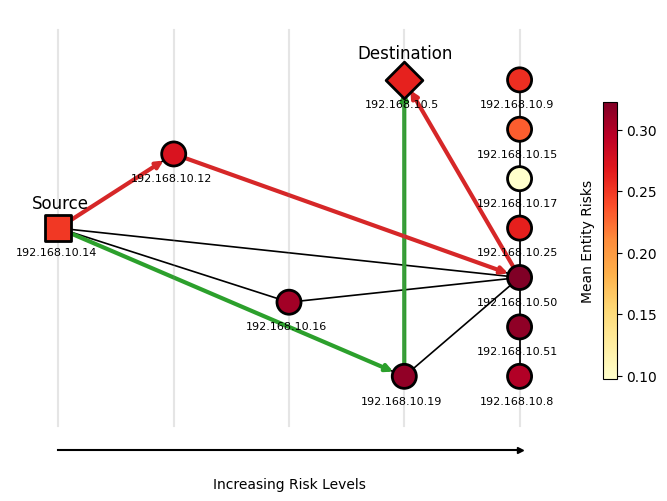

In [64]:


paths_highlight=[[('192.168.10.14', '192.168.10.19'), ('192.168.10.19', '192.168.10.5')],
                 [('192.168.10.14', '192.168.10.12'), ('192.168.10.12', '192.168.10.50'), 
                  ('192.168.10.50', '192.168.10.5')]]
fig = cartesian_dist_plot(g, distances, risk_dict, title='', show_names=True, label_size = 8,
                          destination='192.168.10.5', paths_highlight=paths_highlight)

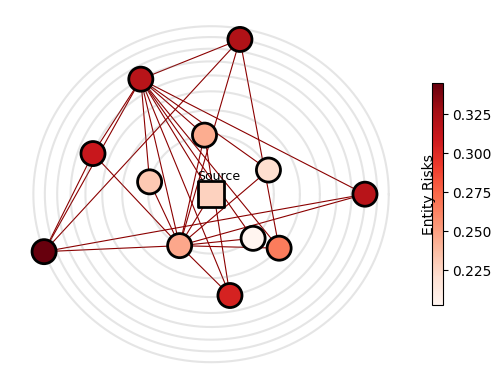

In [13]:
fig = polar_dist_plot(g, distances, risk_dict, '', seed=19) # 95

# MCMC

<Axes: ylabel='max'>

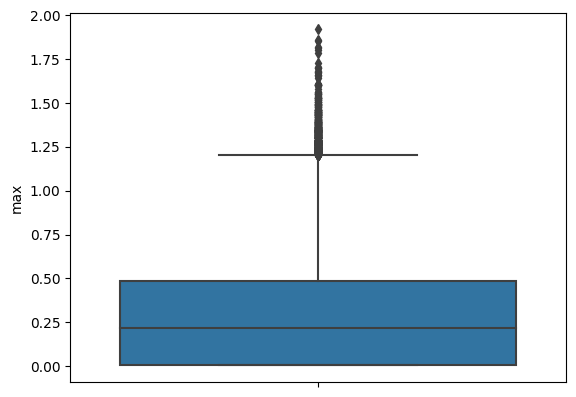

In [68]:

temp_df = naive_mc_max(risk_mean.reshape((-1,)), risk_cov, 10000, 10)
sns.boxplot(data=temp_df, y='max')

Progress: [##############################] 1000 of 1000 samples


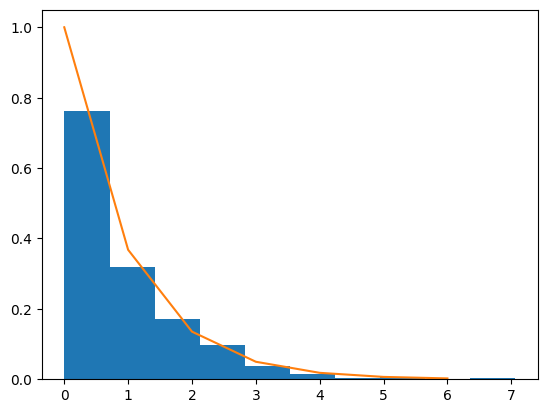

In [9]:
import sampyl.samplers as smp

logp = lambda x: -x if x > 0 else -np.inf
metro = smp.Metropolis(logp, {'x': 1})
samps = metro.sample(1000)
samps.shape
plt.hist(samps.x, density= True)
plt.plot(np.exp(-np.arange(7)))

# Miscellaneous Plots

Text(0, 0.5, '$f_X(x)$')

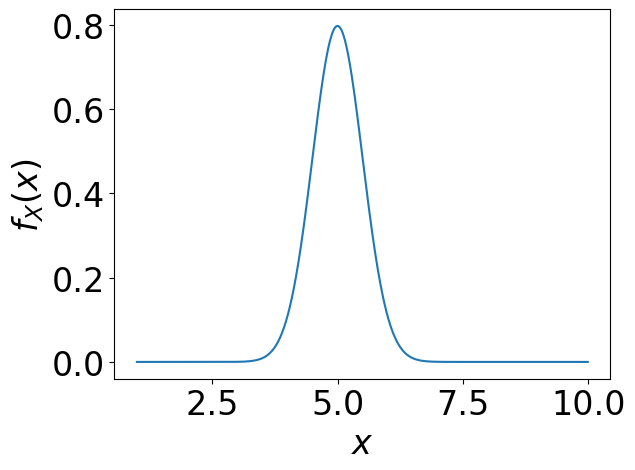

In [103]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import statistics
  
# Plot between -10 and 10 with .001 steps.
x_axis = np.arange(1, 10, 0.01)

plt.rcParams.update({'font.size': 24})
plt.plot(x_axis, norm.pdf(x_axis, 5, 0.5))
plt.xlabel(r'$x$')
plt.ylabel(r'$f_X(x)$')

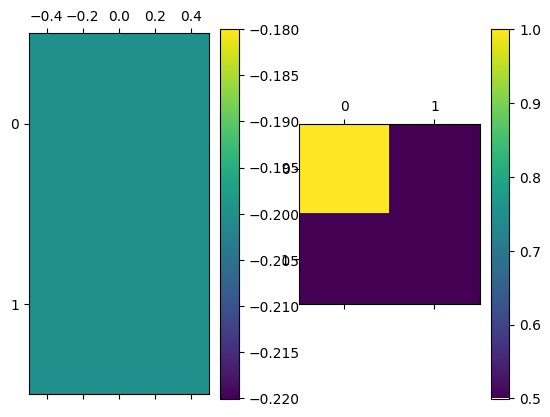

In [21]:
seed = 232
np.random.seed(seed)

n = 2

mu = np.array([-.2,-.2])
cov = np.array([[1, 0.5],
                [0.5, 0.5]])

ax1 = plt.subplot(121)
mat1 = ax1.matshow(mu.reshape((-1, 1)))
plt.colorbar(mat1)
ax2 = plt.subplot(122)
mat2 = ax2.matshow(cov)
plt.colorbar(mat2)

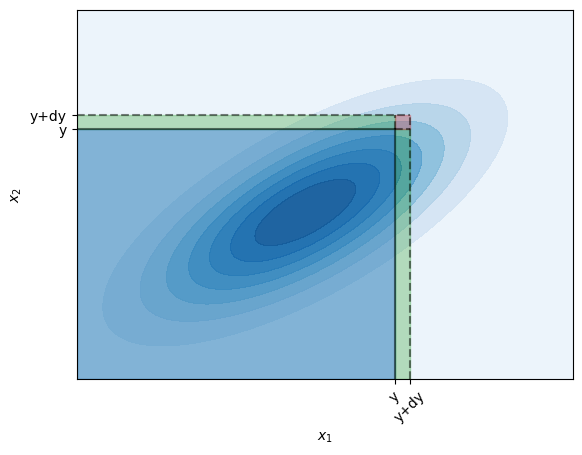

In [79]:
from scipy.stats import multivariate_normal

rv = multivariate_normal(mean= mu, cov= cov, allow_singular=False)

y_min, y_max = -2, 2
x_min, x_max = -2.5, 2.5
eps = 0.15

x, y = np.mgrid[x_min:x_max:.01, y_min:y_max:.01]
pos = np.dstack((x, y))
fig = plt.figure()
ax = fig.add_subplot(111)
ax.contourf(x, y, rv.pdf(pos), alpha= 0.9, cmap='Blues')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
#fig.savefig(fname='./figures/mvn.jpg')

y_val = 0.7
ax.plot([y_val, y_val], [y_min, y_val], color= 'k', alpha= 0.5)#, linestyle='dashed'
ax.plot([x_min, y_val], [y_val, y_val], color= 'k', alpha= 0.5)
ax.set_xticks([y_val], ['y'])
ax.set_yticks([y_val], ['y'])
ax.fill_between([x_min, y_val], [y_min, y_min], [y_val, y_val], color='tab:blue', alpha=0.3)
fig.savefig(fname='./figures/mvn_y.jpg')

ax.plot([y_val, y_val], [y_val, y_val+eps], color= 'k', alpha= 0.5, linestyle='dashed')
ax.plot([y_val, y_val+eps], [y_val, y_val], color= 'k', alpha= 0.5, linestyle='dashed')
ax.plot([y_val+eps, y_val+eps], [y_min, y_val+eps], color= 'k', alpha= 0.5, linestyle='dashed')
ax.plot([x_min, y_val+eps], [y_val+eps, y_val+eps], color= 'k', alpha= 0.5, linestyle='dashed')
ax.set_xticks([y_val, y_val+eps], ['y', 'y+dy'], rotation= 45)
ax.set_yticks([y_val, y_val+eps], ['y', 'y+dy'])
#fig.savefig(fname='./figures/mvn_y_dy.jpg')

ax.fill_between([x_min, y_val], [y_min, y_min], [y_val, y_val], color='tab:blue', alpha=0.3)
ax.fill_between([x_min, y_val], [y_val, y_val], [y_val+eps, y_val+eps], color='tab:green', alpha=0.3)
ax.fill_between([y_val, y_val+eps], [y_min, y_min], [y_val, y_val], color='tab:green', alpha=0.3)
ax.fill_between([y_val, y_val+eps], [y_val, y_val], [y_val+eps, y_val+eps], color='tab:red', alpha=0.3)
#fig.savefig(fname='./figures/mvn_y_dy_shaded.jpg')